In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
spy = yf.download("SPY", start="2020-01-01")
qqq = yf.download("QQQ", start="2020-01-01")
vix = yf.download("^VIX", start="2020-01-01")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [3]:
spy["Returns"] = spy["Close"].pct_change()
spy["Volatility"] = spy["Returns"].rolling(30).std()
spy["Cumulative Returns"] = (1 + spy["Returns"]).cumprod()
spy["Log Returns"] = np.log(spy["Close"] / spy["Close"].shift(1))

spy["MA50"] = spy["Close"].rolling(50).mean()
spy["MA200"] = spy["Close"].rolling(200).mean()

In [4]:
spy = spy.dropna()

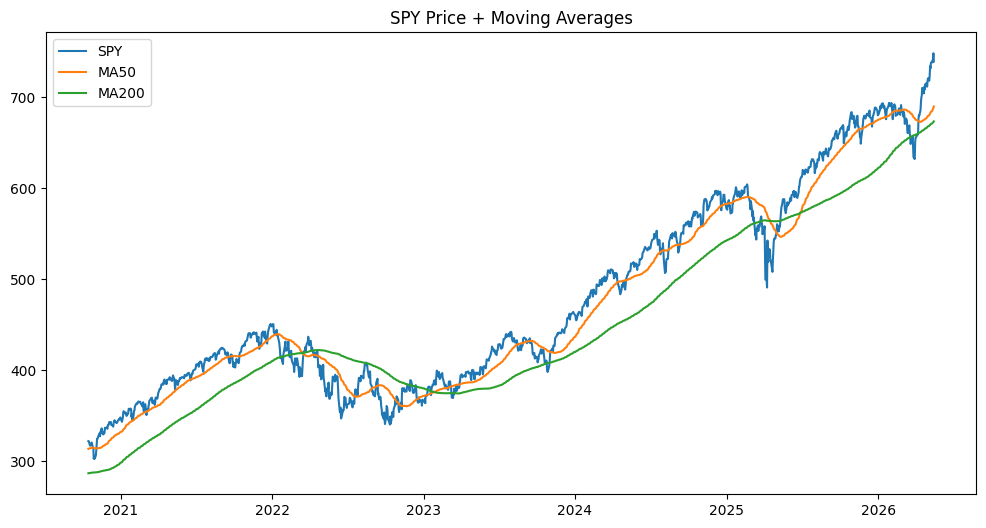

In [5]:
plt.figure(figsize=(12,6))

plt.plot(spy["Close"], label="SPY")
plt.plot(spy["MA50"], label="MA50")
plt.plot(spy["MA200"], label="MA200")

plt.legend()
plt.title("SPY Price + Moving Averages")
plt.show()

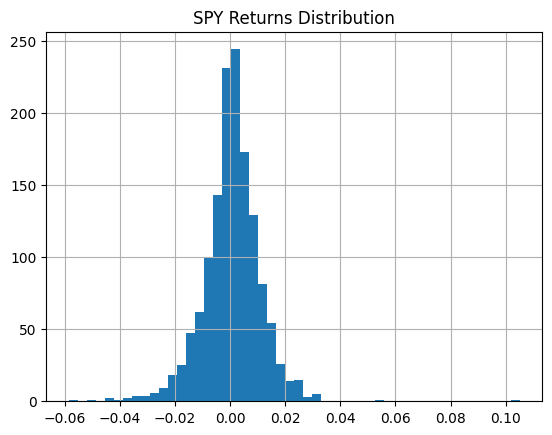

count    1402.000000
mean        0.000648
std         0.010618
min        -0.058543
25%        -0.004397
50%         0.000746
75%         0.006332
max         0.105019
Name: Returns, dtype: float64

In [6]:
spy["Returns"].hist(bins=50)
plt.title("SPY Returns Distribution")
plt.show()

spy["Returns"].describe()

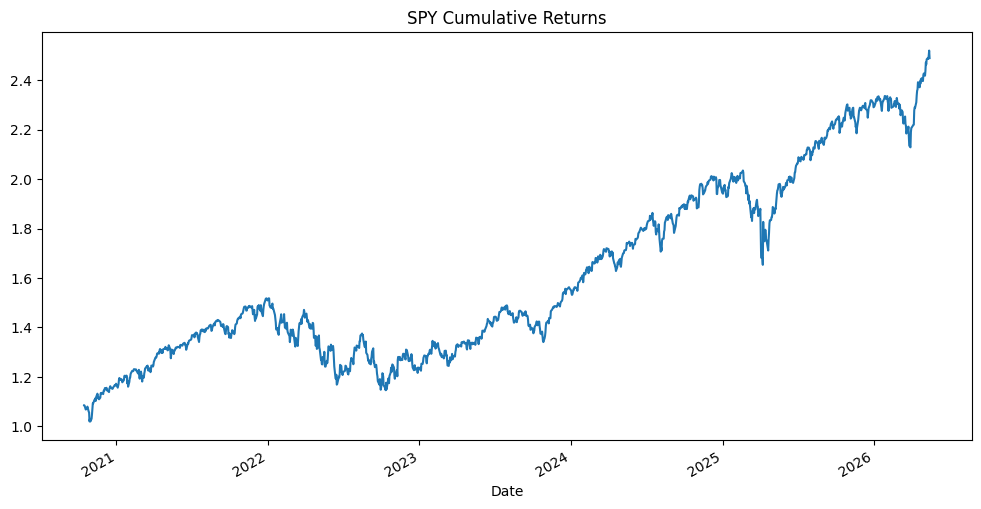

In [7]:
spy["Cumulative Returns"].plot(figsize=(12,6))

plt.title("SPY Cumulative Returns")
plt.show()

In [8]:
qqq["Returns"] = qqq["Close"].pct_change()
vix["Returns"] = vix["Close"].pct_change()

In [9]:
combined = pd.DataFrame({
    "SPY": spy["Returns"],
    "QQQ": qqq["Returns"],
    "VIX": vix["Returns"]
})

In [10]:
combined.corr()

,SPY,QQQ,VIX
SPY,1.000000,0.941315,-0.747978
QQQ,0.941315,1.000000,-0.692791
VIX,-0.747978,-0.692791,1.000000


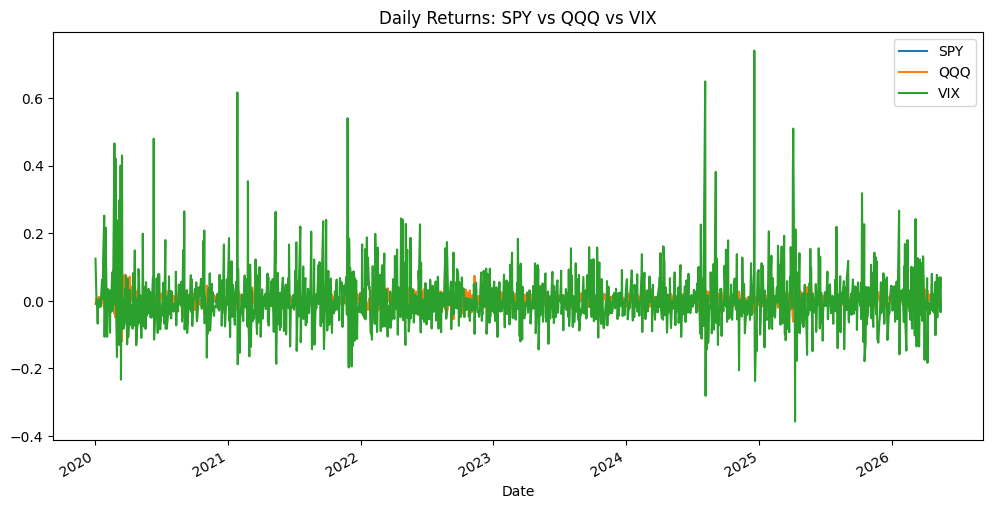

In [11]:
combined.plot(figsize=(12,6))

plt.title("Daily Returns: SPY vs QQQ vs VIX")
plt.show()

In [12]:
combined["SPY_QQQ_corr"] = combined["SPY"].rolling(30).corr(combined["QQQ"])
combined["SPY_VIX_corr"] = combined["SPY"].rolling(30).corr(combined["VIX"])

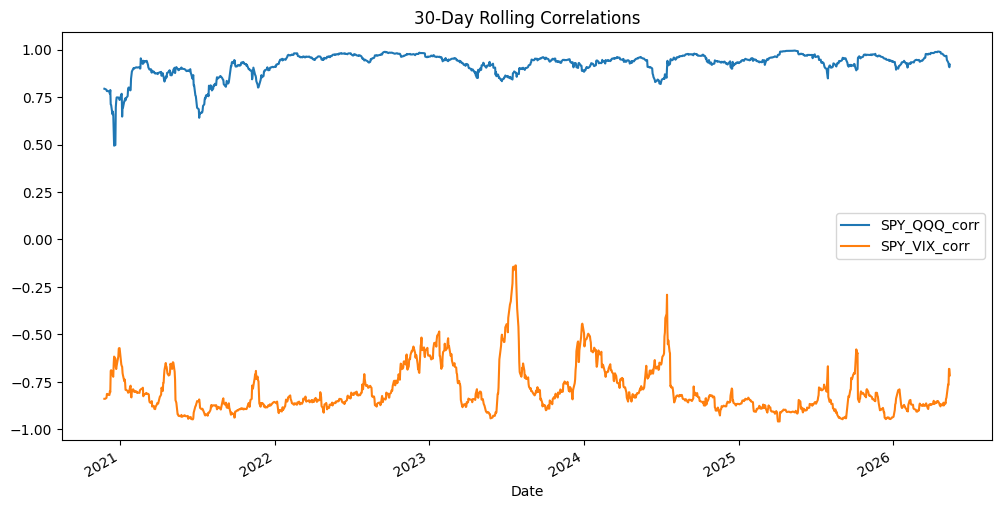

In [13]:
combined[["SPY_QQQ_corr", "SPY_VIX_corr"]].plot(figsize=(12,6))

plt.title("30-Day Rolling Correlations")
plt.show()